# AAE 625 Homework 3: Elasticity & CPI Data Analysis with Python
**Alina’s homework 3 code   ———— Authors: alina & chatgpt & gemini**

This notebook answers all questions in the assignment using the uploaded data files:

- `RetailData_A202602.csv`
- `CPIAUCSL_26.xlsx`

I use **arc elasticity** for the demand schedule in Part 1 because the homework asks for elasticity for each discrete price change.


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

def find_file(candidates):
    search_roots = [Path.cwd(), Path("/mnt/data")]
    for root in search_roots:
        for name in candidates:
            path = root / name
            if path.exists():
                return path
    raise FileNotFoundError(f"Could not find any of: {candidates}")

retail_path = find_file(["RetailData_A202602.csv", "RetailData.csv"])
cpi_path = find_file(["CPIAUCSL_26.xlsx", "CPIAUCSL.xlsx"])

print("Retail data file:", retail_path)
print("CPI data file:", cpi_path)


Retail data file: /mnt/data/RetailData_A202602.csv
CPI data file: /mnt/data/CPIAUCSL_26.xlsx


## Part 1: Elasticity Practice

### Question 1. Create the Demand Schedule DataFrame and Compute Elasticity

The table below reproduces the given demand schedule.  
For each adjacent price change, I compute **price elasticity of demand (PED)** using the **midpoint / arc elasticity formula**:

\[
PED = \frac{(Q_2-Q_1)/\left[(Q_1+Q_2)/2\right]}{(P_2-P_1)/\left[(P_1+P_2)/2\right]}
\]

This is appropriate here because the prices change in discrete steps rather than infinitesimally.


In [2]:

demand = pd.DataFrame({
    "Price": [1, 2, 3, 4, 5, 6, 6.5, 7, 8, 9, 10],
    "Quantity": [100, 90, 80, 70, 60, 50, 45, 40, 30, 20, 10]
})

demand["Midpoint Price"] = (demand["Price"] + demand["Price"].shift(1)) / 2
demand["Midpoint Quantity"] = (demand["Quantity"] + demand["Quantity"].shift(1)) / 2
demand["Arc %ΔQ"] = (demand["Quantity"] - demand["Quantity"].shift(1)) / demand["Midpoint Quantity"]
demand["Arc %ΔP"] = (demand["Price"] - demand["Price"].shift(1)) / demand["Midpoint Price"]
demand["PED (arc)"] = demand["Arc %ΔQ"] / demand["Arc %ΔP"]

display(demand.round(4))


,Price,Quantity,Midpoint Price,Midpoint Quantity,Arc %ΔQ,Arc %ΔP,PED (arc)
0,1.0,100,NaN,NaN,NaN,NaN,NaN
1,2.0,90,1.50,95.0,-0.1053,0.6667,-0.1579
2,3.0,80,2.50,85.0,-0.1176,0.4000,-0.2941
3,4.0,70,3.50,75.0,-0.1333,0.2857,-0.4667
4,5.0,60,4.50,65.0,-0.1538,0.2222,-0.6923
5,6.0,50,5.50,55.0,-0.1818,0.1818,-1.0000
6,6.5,45,6.25,47.5,-0.1053,0.0800,-1.3158
7,7.0,40,6.75,42.5,-0.1176,0.0741,-1.5882
8,8.0,30,7.50,35.0,-0.2857,0.1333,-2.1429
9,9.0,20,8.50,25.0,-0.4000,0.1176,-3.4000


**Interpretation:** The demand schedule becomes more elastic as price rises and quantity falls.  
At the price change from **$5 to $6**, the arc elasticity is **-1.00**, which is unit elastic.  
At lower prices demand is inelastic in absolute value, while at higher prices it becomes increasingly elastic.

### Question 2. Plot the Demand Curve and Price Elasticity

The figure below uses a dual axis:

- **Left y-axis:** quantity demanded
- **Right y-axis:** arc price elasticity of demand
- **x-axis:** price level

For the elasticity line, I plot the value at each **midpoint price**, since each elasticity belongs to the price interval between two adjacent observations.


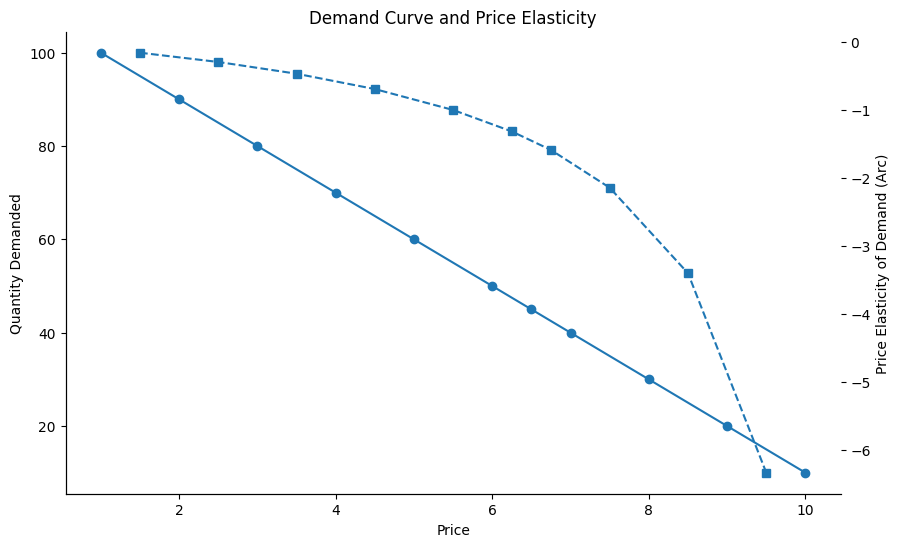

In [3]:

fig, ax1 = plt.subplots()

ax1.plot(demand["Price"], demand["Quantity"], marker="o")
ax1.set_xlabel("Price")
ax1.set_ylabel("Quantity Demanded")
ax1.set_title("Demand Curve and Price Elasticity")

elasticity_points = demand.dropna(subset=["PED (arc)"]).copy()
ax2 = ax1.twinx()
ax2.plot(elasticity_points["Midpoint Price"], elasticity_points["PED (arc)"], marker="s", linestyle="--")
ax2.set_ylabel("Price Elasticity of Demand (Arc)")

plt.show()


### Question 3. Log–Log Elasticity Model

The assignment gives the model:

\[
\ln(Q) = \beta_0 + \beta_1 \ln(P) + \beta_2 \ln(R) + \beta_3 \ln(C) + \beta_4 \ln(I) + \beta_5 \ln(S) + \varepsilon
\]

where:

- \(Q\) = quantity sold  
- \(P\) = price  
- \(R\) = percent renters  
- \(C\) = percent households with children  
- \(I\) = income  
- \(S\) = percent Spanish speaking


In [4]:

retail = pd.read_csv(retail_path)

# Drop the saved row index column if it exists
if "Unnamed: 0" in retail.columns:
    retail = retail.drop(columns=["Unnamed: 0"])

df = retail.rename(columns={
    "PRICE": "P",
    "QUANTITY": "Q",
    "PERCENTAGE_OF_RENTERS": "R",
    "PERCENT_HAVING_CHILDREN": "C",
    "AVERAGE_INCOME": "I",
    "PERCENT_SPEAKING_SPANISH": "S"
}).copy()

for col in ["Q", "P", "R", "C", "I", "S"]:
    df[f"ln_{col}"] = np.log(df[col])

model = smf.ols("ln_Q ~ ln_P + ln_R + ln_C + ln_I + ln_S", data=df).fit()

coef_table = pd.DataFrame({
    "Coefficient": model.params,
    "Std. Error": model.bse,
    "t-stat": model.tvalues,
    "p-value": model.pvalues
}).round(4)

display(coef_table)
print(model.summary())


,Coefficient,Std. Error,t-stat,p-value
Intercept,8.7401,0.7064,12.3728,0.0000
ln_P,-0.6419,0.2511,-2.5560,0.0111
ln_R,0.3377,0.0287,11.7564,0.0000
ln_C,0.7993,0.0869,9.1967,0.0000
ln_I,0.5554,0.0504,11.0169,0.0000
ln_S,0.2607,0.0235,11.1153,0.0000


                            OLS Regression Results                            
Dep. Variable:                   ln_Q   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     113.1
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           1.47e-65
Time:                        18:51:24   Log-Likelihood:                -30.391
No. Observations:                 291   AIC:                             72.78
Df Residuals:                     285   BIC:                             94.82
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.7401      0.706     12.373      0.0

### Written answers for Question 3

- **Estimated price elasticity:** The estimated price elasticity is **-0.6419**.
- **Elastic or inelastic?** Demand is **inelastic**, because the absolute value of the price elasticity is less than 1.
- **Statistical significance:** The price coefficient has a **p-value of 0.0111**, so it is statistically significant at the 5% level.
- **How demographic variables affect demand:** The coefficients on renters (**0.3377**), households with children (**0.7993**), income (**0.5554**), and percent Spanish speaking (**0.2607**) are all positive and statistically significant. Holding the other variables constant, stores in areas with more renters, more households with children, higher incomes, and more Spanish-speaking residents tend to sell more.
- **Economic interpretation of income:** Because this is a log–log model, the income coefficient is an elasticity. A **1% increase in average income is associated with about a 0.555% increase in quantity sold**, all else equal. This suggests the product behaves like a **normal good**, and demand is income-inelastic because the coefficient is positive but below 1.


## Part 2: CPI Data Analysis

### Question 4. Data Loading and Exploration

This section loads the CPI data from the **Monthly** sheet, parses the date column, sets it as the index, and reports the first/last rows, date range, number of observations, and missing values.


First 5 rows:


,CPIAUCSL
observation_date,
1947-01-01,21.48
1947-02-01,21.62
1947-03-01,22.00
1947-04-01,22.00
1947-05-01,21.95


Last 5 rows:


,CPIAUCSL
observation_date,
2025-10-01,NaN
2025-11-01,325.063
2025-12-01,326.031
2026-01-01,326.588
2026-02-01,327.460


Number of observations: 950
Date range: 1947-01-01 to 2026-02-01
Missing values by column:


CPIAUCSL    1
dtype: int64

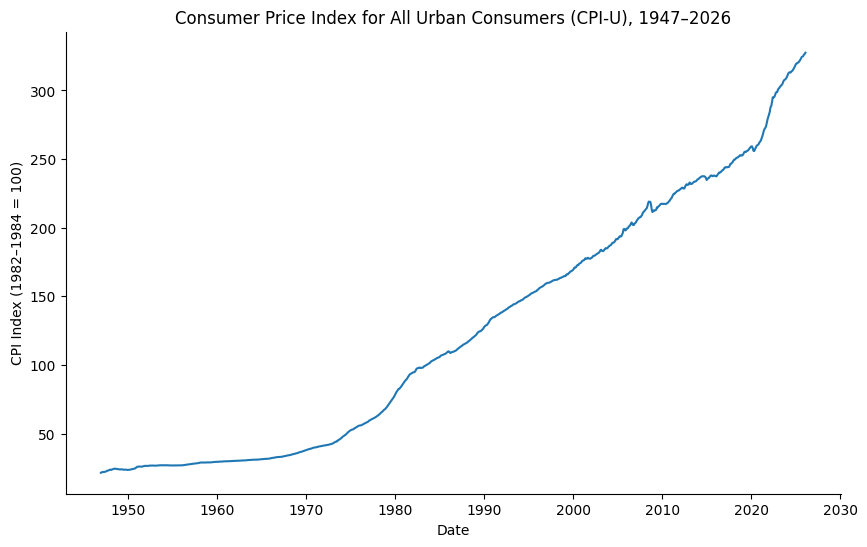

In [5]:

cpi = pd.read_excel(cpi_path, sheet_name="Monthly", parse_dates=["observation_date"])
cpi = cpi.set_index("observation_date").sort_index()

print("First 5 rows:")
display(cpi.head())

print("Last 5 rows:")
display(cpi.tail())

print("Number of observations:", len(cpi))
print("Date range:", cpi.index.min().date(), "to", cpi.index.max().date())
print("Missing values by column:")
display(cpi.isna().sum())

plt.figure()
plt.plot(cpi.index, cpi["CPIAUCSL"])
plt.title("Consumer Price Index for All Urban Consumers (CPI-U), 1947–2026")
plt.xlabel("Date")
plt.ylabel("CPI Index (1982–1984 = 100)")
plt.show()


**Answer:** The CPI file contains **950 observations** covering **January 1947 to February 2026**.  
There is **1 missing CPI value**, which occurs in **2025-10**.

### Question 5. Year-over-Year Inflation Rate

YoY inflation is calculated as:

\[
\pi_t = \frac{CPI_t - CPI_{t-12}}{CPI_{t-12}} \times 100
\]

I compute the new column, plot YoY inflation from 2000 onward, add a horizontal dashed line at 2%, and then answer the specific questions.


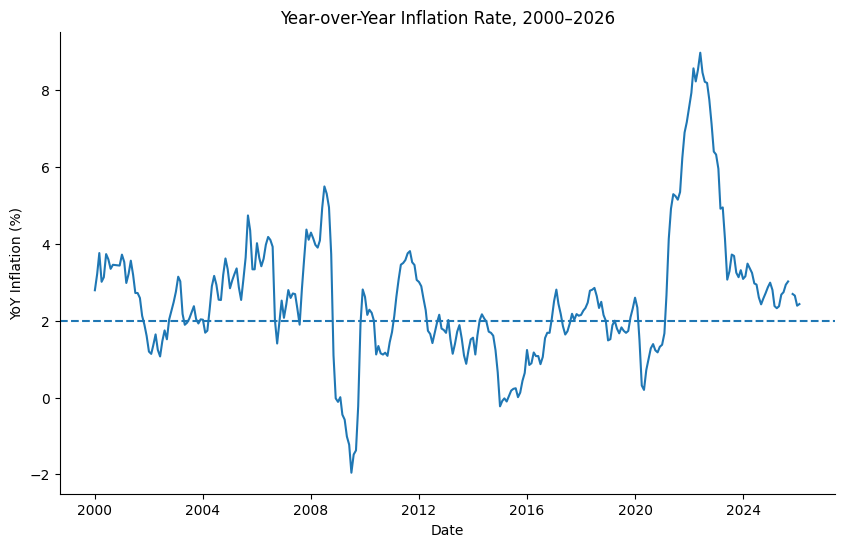

YoY inflation in January 2026: 2.3912%
Highest YoY inflation since 2000: 8.9794% in June 2022


In [6]:

cpi["YoY Inflation"] = cpi["CPIAUCSL"].pct_change(12, fill_method=None) * 100

plt.figure()
subset_yoy = cpi.loc["2000-01-01":"2026-12-31", "YoY Inflation"]
plt.plot(subset_yoy.index, subset_yoy.values)
plt.axhline(2, linestyle="--")
plt.title("Year-over-Year Inflation Rate, 2000–2026")
plt.xlabel("Date")
plt.ylabel("YoY Inflation (%)")
plt.show()

jan_2026_yoy = cpi.loc["2026-01-01", "YoY Inflation"]
highest_date = cpi.loc["2000-01-01":, "YoY Inflation"].idxmax()
highest_rate = cpi.loc["2000-01-01":, "YoY Inflation"].max()

print(f"YoY inflation in January 2026: {jan_2026_yoy:.4f}%")
print(f"Highest YoY inflation since 2000: {highest_rate:.4f}% in {highest_date.strftime('%B %Y')}")


### Written answers for Question 5

- **YoY inflation rate for January 2026:** **2.39%**
- **Highest YoY inflation since 2000:** **8.98% in June 2022**

**Economic context:** The inflation peak in June 2022 reflects the unusually strong inflation surge that followed the COVID period. Demand rebounded quickly as the economy reopened, while supply chains were still disrupted and energy and food prices were pushed up by global shocks. In course terms, this period combined **demand-pull inflation**, **cost-push inflation**, and lingering **supply bottlenecks**.


### Question 6. Month-over-Month Inflation

MoM inflation is calculated as:

\[
MoM_t = \frac{CPI_t - CPI_{t-1}}{CPI_{t-1}} \times 100
\]

The file contains one missing CPI observation in October 2025, so MoM inflation is unavailable for that month and the immediately following month. For the chart below, I use the **most recent 24 available MoM observations**.


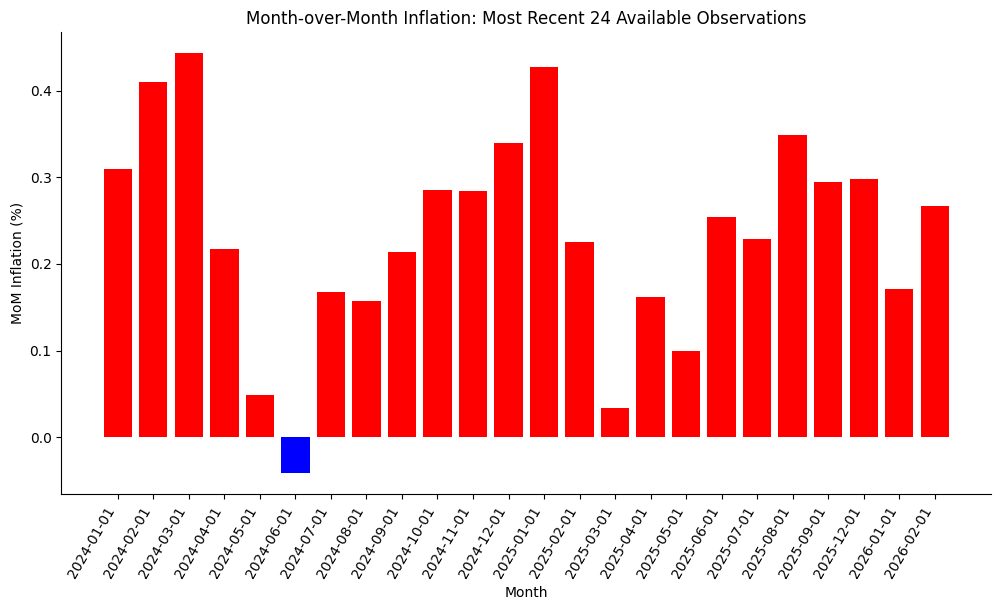

,MoM Inflation
observation_date,
2024-01-01,0.3100
2024-02-01,0.4098
2024-03-01,0.4431
2024-04-01,0.2171
2024-05-01,0.0486
2024-06-01,-0.0418
2024-07-01,0.1677
2024-08-01,0.1572
2024-09-01,0.2133


In [7]:

cpi["MoM Inflation"] = cpi["CPIAUCSL"].pct_change(1, fill_method=None) * 100

recent_mom = cpi["MoM Inflation"].dropna().tail(24)
colors = ["red" if x >= 0 else "blue" for x in recent_mom]

plt.figure(figsize=(12, 6))
plt.bar(recent_mom.index.astype(str), recent_mom.values, color=colors)
plt.xticks(rotation=60, ha="right")
plt.title("Month-over-Month Inflation: Most Recent 24 Available Observations")
plt.xlabel("Month")
plt.ylabel("MoM Inflation (%)")
plt.show()

display(recent_mom.to_frame().round(4))


**Why economists usually prefer YoY over MoM:** YoY inflation compares a month with the same month one year earlier, so it smooths out seasonality and short-run noise. MoM inflation can swing because of one-time shocks, timing effects, or temporary price changes, which makes it less reliable for judging the broader inflation trend. Policymakers therefore often use YoY inflation when communicating medium-run inflation pressure.

### Question 7. Comparing Inflation Across Periods

I compute the **average YoY inflation rate** within each period and compare the results in a bar chart.


,Average YoY Inflation (%)
2000–2007,2.7769
2008–2009,1.7592
2010–2019,1.7713
2020–2023,4.5190
2024–2026,2.7955


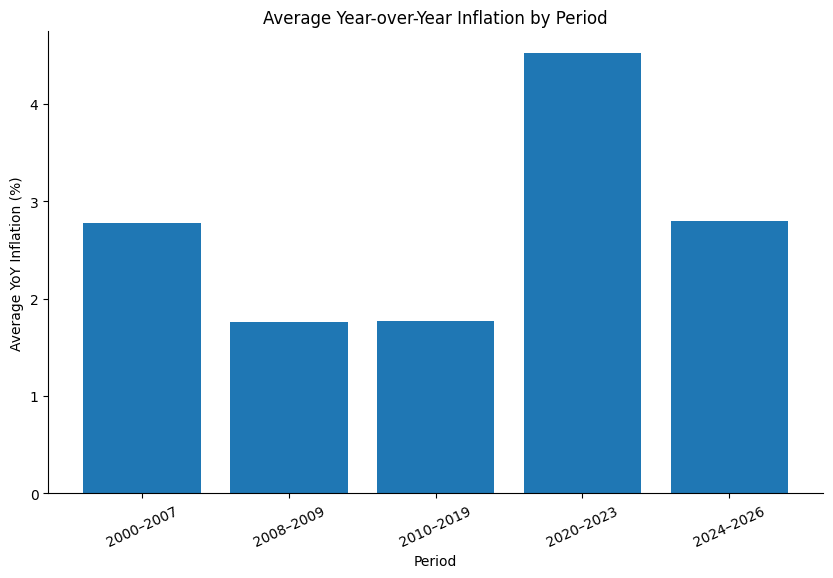

In [8]:

periods = {
    "2000–2007": ("2000-01-01", "2007-12-31"),
    "2008–2009": ("2008-01-01", "2009-12-31"),
    "2010–2019": ("2010-01-01", "2019-12-31"),
    "2020–2023": ("2020-01-01", "2023-12-31"),
    "2024–2026": ("2024-01-01", "2026-12-31")
}

period_avg = pd.Series({
    name: cpi.loc[start:end, "YoY Inflation"].mean()
    for name, (start, end) in periods.items()
})

display(period_avg.round(4).to_frame(name="Average YoY Inflation (%)"))

plt.figure()
plt.bar(period_avg.index, period_avg.values)
plt.title("Average Year-over-Year Inflation by Period")
plt.xlabel("Period")
plt.ylabel("Average YoY Inflation (%)")
plt.xticks(rotation=25)
plt.show()


### Written answers for Question 7

- **2000–2007:** Average YoY inflation was **2.78%**. This was a relatively stable expansion period, but inflation was supported by strong demand, rising housing activity, and increases in commodity and energy prices toward the middle and end of the decade. In course terms, this period shows moderate **demand-pull** pressure with some **cost-push** influence from oil and commodities.

- **2008–2009:** Average YoY inflation was **1.76%**. The financial crisis sharply weakened aggregate demand, and the recession reduced inflation pressure substantially. This period fits a weak-demand environment in which falling spending and labor market slack pulled inflation down.

- **2010–2019:** Average YoY inflation was **1.77%**. During the recovery, inflation stayed relatively subdued despite continued economic growth. Global competition, anchored inflation expectations, and accommodative but controlled monetary policy helped keep inflation low and stable.

- **2020–2023:** Average YoY inflation was **4.52%**. This period includes the pandemic recession and the later inflation surge. Large policy stimulus, reopening demand, supply-chain disruptions, labor shortages, and energy shocks combined to generate both **demand-pull** and **cost-push** inflation.

- **2024–2026:** Average YoY inflation was **2.80%** using the available observations in the file. Inflation appears lower than the 2022 peak but still above the very low-inflation era of the 2010s. This suggests that tighter monetary policy and improved supply conditions have reduced inflation pressure, although price growth has not fully disappeared.
